In [ ]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
import os
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [2]:
from mem0 import Memory

config = {
    "vector_store": {
        "provider": "milvus", 
        "config": {
            "collection_name": "quickstart_mem0_with_milvus",
            "embedding_model_dims": "1536",
            "url":"http://localhost:19530"
        }
    }
}
m = Memory.from_config(config)
res = m.add(
    messages="I am working on improving my tennis skills.", 
    user_id="alice",
    metadata={"category":"hobbies"},
)

res

/home/chhabi/Desktop/engineering/mem0/.venv/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.27.2 is exactly one major version older than the runtime version 6.31.1 at schema.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/chhabi/Desktop/engineering/mem0/.venv/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.27.2 is exactly one major version older than the runtime version 6.31.1 at common.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/home/chhabi/Desktop/engineering/mem0/.venv/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.27.2 is exactly one major version older than the runtime version 6.31.1 at milvus.proto. Please update the gencode to avoid compatibility violations in th

MilvusException: <MilvusException: (code=2, message=Fail connecting to server on localhost:19530, illegal connection params or server unavailable)>

In [11]:
m.get_all(user_id="alice")

{'results': [{'id': '6c83f67a-b827-438a-9ef9-467b50214e4a',
   'memory': 'Working on improving tennis skills',
   'hash': '4c3bc9f87b78418f19df6407bc86e006',
   'metadata': {'category': 'hobbies'},
   'created_at': '2025-08-09T04:23:50.483716-07:00',
   'updated_at': None,
   'user_id': 'alice'}]}

In [8]:
m.add(
    messages="I have chess skills. And I am also working on the strategies to gain knowledge of chess",
    user_id= "alice",
    metadata={"category": "hobbies"}
)

{'results': [{'id': 'a509c0ea-03bd-4b52-a193-eef0f40b99c9',
   'memory': 'Has chess skills',
   'event': 'ADD'},
  {'id': '645db603-ebc5-4b47-81e8-b68af79dab4b',
   'memory': 'Is working on strategies to gain knowledge of chess',
   'event': 'ADD'}]}

In [9]:
m.get_all(user_id="alice")

{'results': [{'id': '645db603-ebc5-4b47-81e8-b68af79dab4b',
   'memory': 'Is working on strategies to gain knowledge of chess',
   'hash': 'c469b5477e220278647468dbc7e89ea9',
   'metadata': {'category': 'hobbies'},
   'created_at': '2025-08-09T01:16:54.339060-07:00',
   'updated_at': None,
   'user_id': 'alice'},
  {'id': 'a509c0ea-03bd-4b52-a193-eef0f40b99c9',
   'memory': 'Has chess skills',
   'hash': '9158314d02d7a767cd21b2410b8a23ed',
   'metadata': {'category': 'hobbies'},
   'created_at': '2025-08-09T01:16:54.332239-07:00',
   'updated_at': None,
   'user_id': 'alice'},
  {'id': 'b739b91b-02cf-4fbd-9410-84980c07b5be',
   'memory': 'Working on improving tennis skills',
   'hash': '4c3bc9f87b78418f19df6407bc86e006',
   'metadata': {'category': 'hobbies'},
   'created_at': '2025-08-09T01:06:45.733155-07:00',
   'updated_at': None,
   'user_id': 'alice'}]}

# NEO4J

In [24]:
from neo4j import GraphDatabase
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import ArrowStyle
from netgraph import Graph as ngGraph


def display_graph():
    # Neo4j connection configuration
    uri = URL
    username = USERNAME
    password = PASSWORD

    # Connect to Neo4j
    driver = GraphDatabase.driver(uri, auth=(username, password))

    # Updated query to return node names
    query = """
    MATCH (n)
    OPTIONAL MATCH (n)-[r]->(m)
    RETURN n.name AS source_name, type(r) AS relationship_type, m.name AS target_name
    """

    # Function to execute the query and process results
    def get_graph_data(tx):
        result = tx.run(query)
        nodes = set()
        edges = []
        for record in result:
            source_name = record["source_name"]
            target_name = record["target_name"]
            relationship = record["relationship_type"]

            if source_name:
                nodes.add(source_name)
            if target_name:
                nodes.add(target_name)
                edges.append((source_name, target_name, relationship))

        return list(nodes), edges

    # Execute the query and get results
    with driver.session() as session:
        nodes, edges = session.execute_read(get_graph_data)

    # Create a NetworkX directed graph
    G = nx.DiGraph()

    # Add nodes and edges to the graph
    G.add_nodes_from(nodes)
    G.add_edges_from([(source, target, {'type': rel_type}) for source, target, rel_type in edges])

    # Set up the plot
    fig, ax = plt.subplots(figsize=(15, 12))
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # Use netgraph for layout and drawing
    try:
        plot_instance = ngGraph(G, node_layout='spring', node_size=5, node_color='lightblue',
                        edge_width=0.4, edge_alpha=1, edge_color='black',
                        node_labels=True, edge_labels=nx.get_edge_attributes(G, 'type'),
                        arrows=True, ax=ax, arrowsize=1,
                        edge_arrow_width=0.5,
                        node_label_fontdict={'size': 12})
    except:
        plt.clf()
        plt.close(fig)
        ax.clear()
        plt.close('all')
        return "Nothing to Plot, add memories"

    plt.title("Mem0 Graph Memory Visualization", fontsize=20)

    # Enable zoom and pan
    def zoom_factory(ax, base_scale=2.):
        def zoom_fun(event):
            cur_xlim = ax.get_xlim()
            cur_ylim = ax.get_ylim()
            xdata = event.xdata
            ydata = event.ydata
            if event.button == 'up':
                scale_factor = 1/base_scale
            elif event.button == 'down':
                scale_factor = base_scale
            else:
                scale_factor = 1
            new_width = (cur_xlim[1] - cur_xlim[0]) * scale_factor
            new_height = (cur_ylim[1] - cur_ylim[0]) * scale_factor
            relx = (cur_xlim[1] - xdata)/(cur_xlim[1] - cur_xlim[0])
            rely = (cur_ylim[1] - ydata)/(cur_ylim[1] - cur_ylim[0])
            ax.set_xlim([xdata - new_width * (1-relx), xdata + new_width * (relx)])
            ax.set_ylim([ydata - new_height * (1-rely), ydata + new_height * (rely)])
            plt.draw()
        fig = ax.get_figure()
        fig.canvas.mpl_connect('scroll_event', zoom_fun)
        return zoom_fun

    zoom = zoom_factory(ax)

    def on_press(event):
        if event.inaxes != ax: return
        ax._pan_start = (event.x, event.y)

    def on_release(event):
        if event.inaxes != ax: return
        ax._pan_start = None

    def on_motion(event):
        if event.inaxes != ax: return
        if not ax._pan_start: return
        dx = event.x - ax._pan_start[0]
        dy = event.y - ax._pan_start[1]
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        scale_x = (xlim[1] - xlim[0]) / ax.get_window_extent().width
        scale_y = (ylim[1] - ylim[0]) / ax.get_window_extent().height
        ax.set_xlim(xlim - dx * scale_x)
        ax.set_ylim(ylim + dy * scale_y)
        ax._pan_start = (event.x, event.y)
        plt.draw()

    fig.canvas.mpl_connect('button_press_event', on_press)
    fig.canvas.mpl_connect('button_release_event', on_release)
    fig.canvas.mpl_connect('motion_notify_event', on_motion)

    plt.show()

    # Close the driver connection
    driver.close()

In [32]:
URL= "bolt://localhost:7687"
USERNAME="neo4j"
PASSWORD="neo4j123"

In [33]:
from mem0 import Memory

config = {
    "llm":{
        "provider": "openai",
        "config": {
            "model": "gpt-4o-mini",
            "temperature": 0
        }
    },
    "graph_store": {
        "provider": "neo4j",
        "config": {
            "url": URL,
            "username":USERNAME,
            "password":PASSWORD
        }
    }
}
m_neo = Memory.from_config(config_dict=config)
user_id = "chhabi"

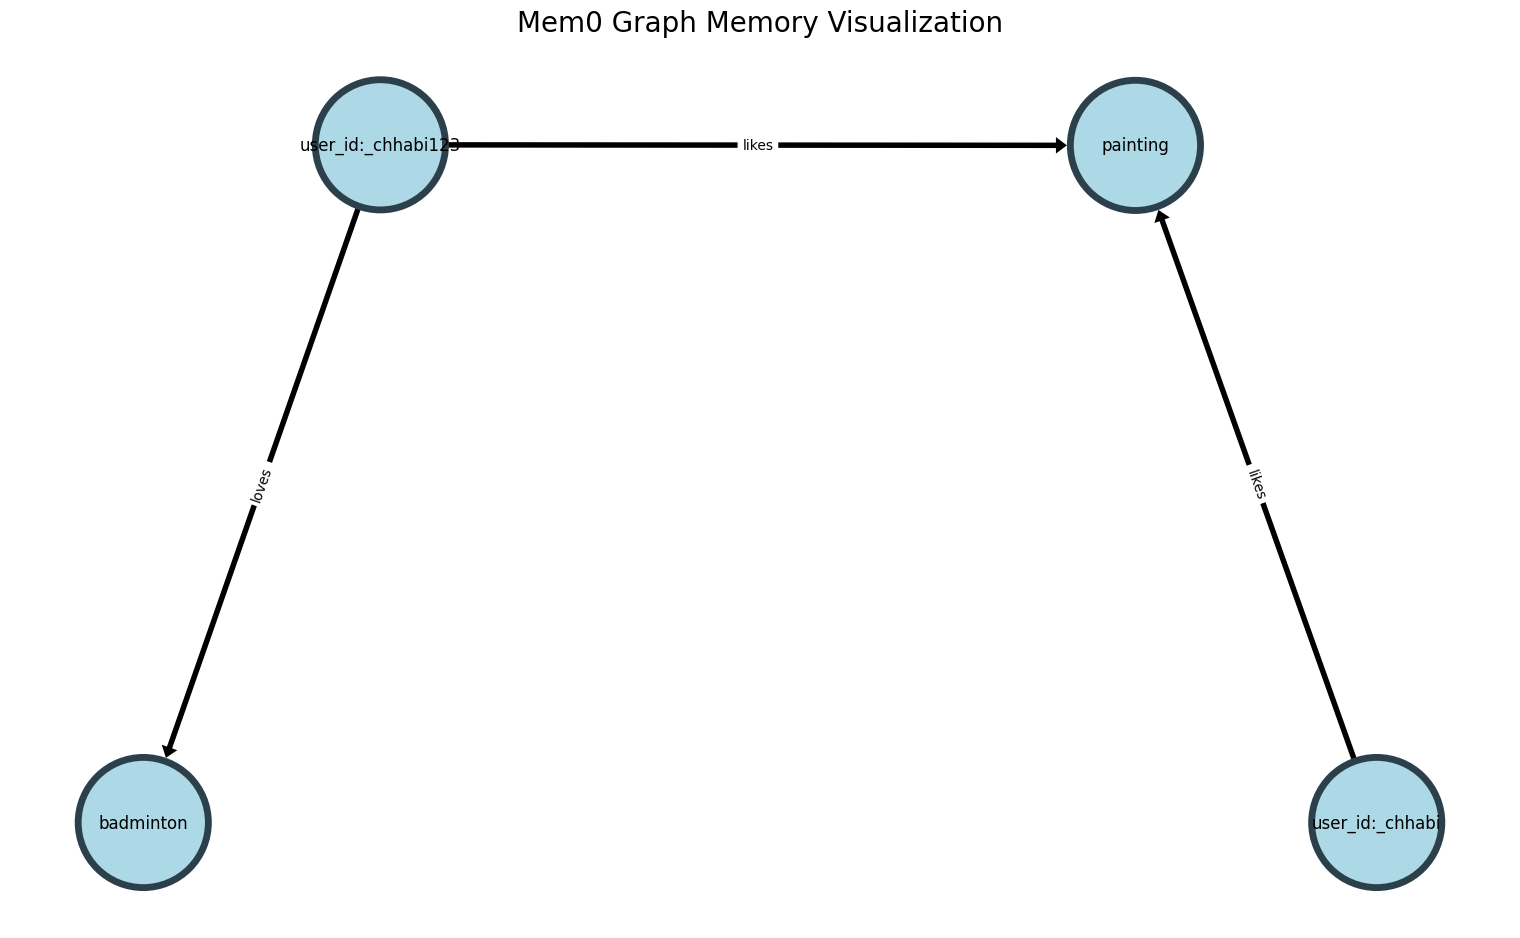

In [34]:
m_neo.add("I like painting.", user_id=user_id)
display_graph()

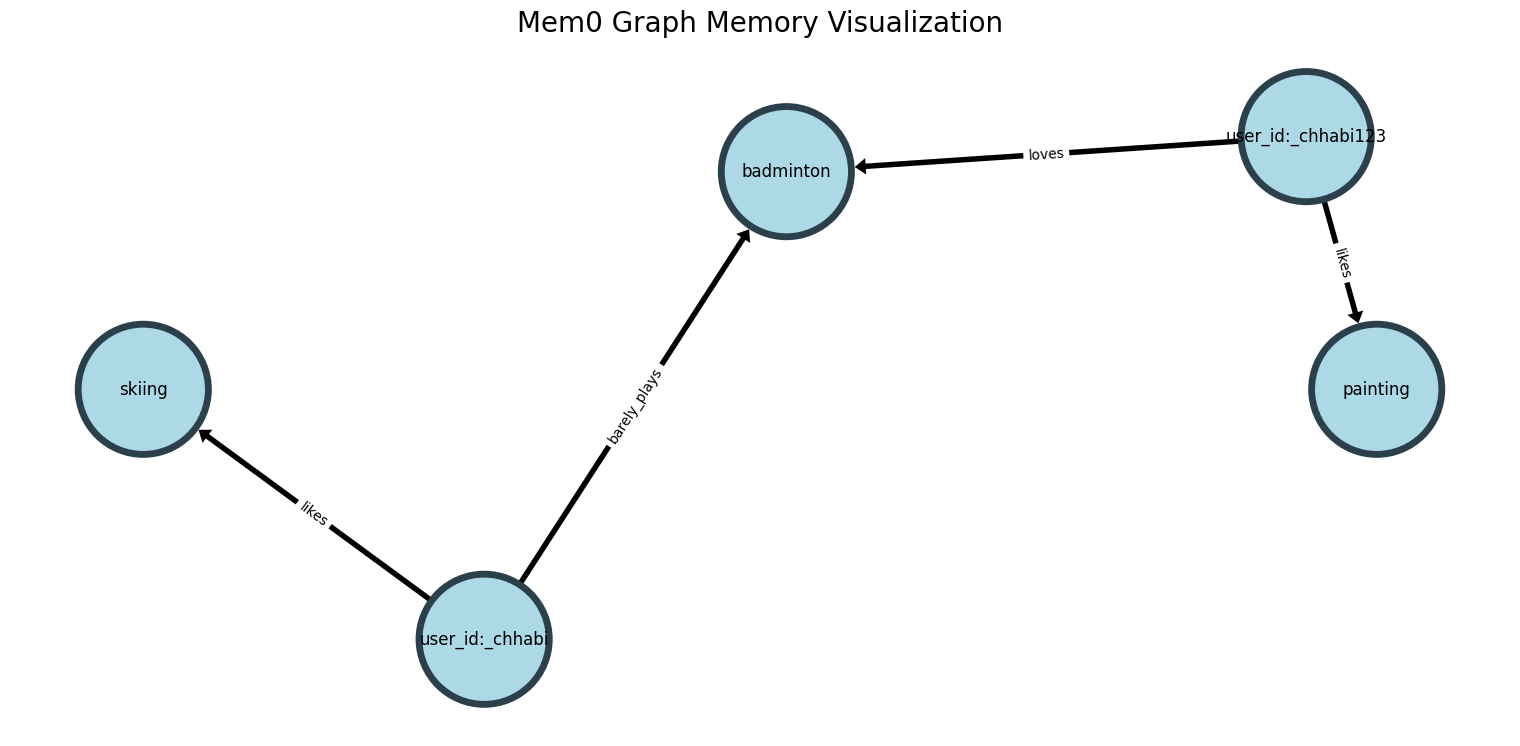

In [36]:
m_neo.add("I like mostly sking and barely play badminton.", user_id=user_id)
display_graph()

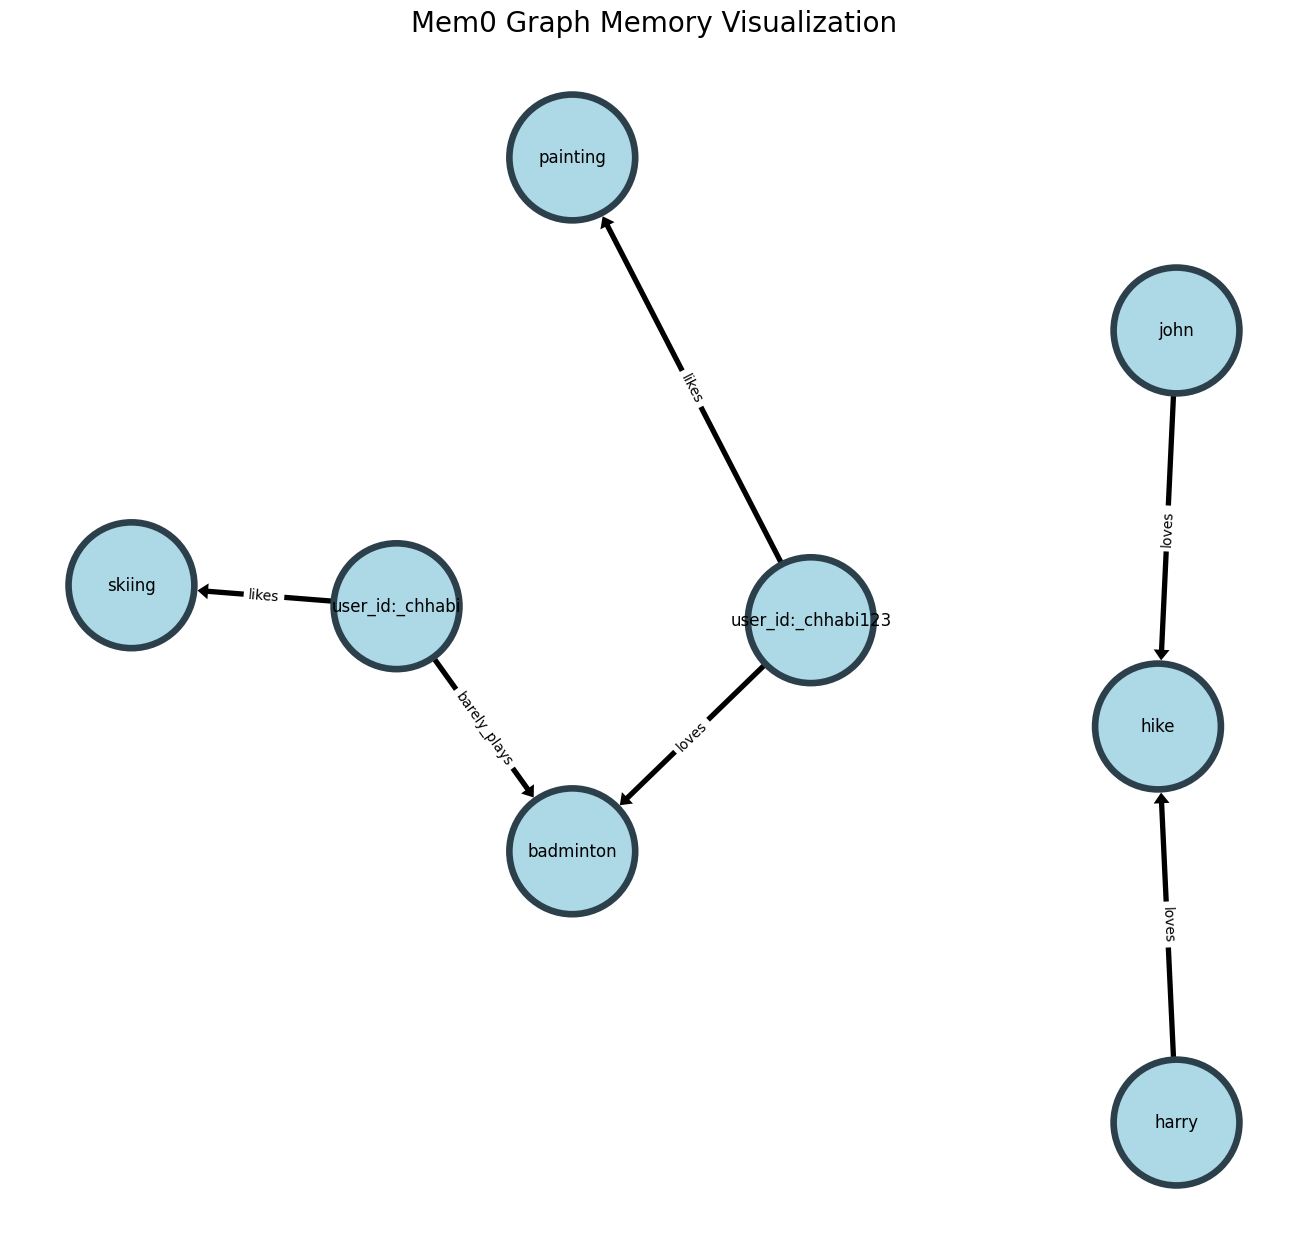

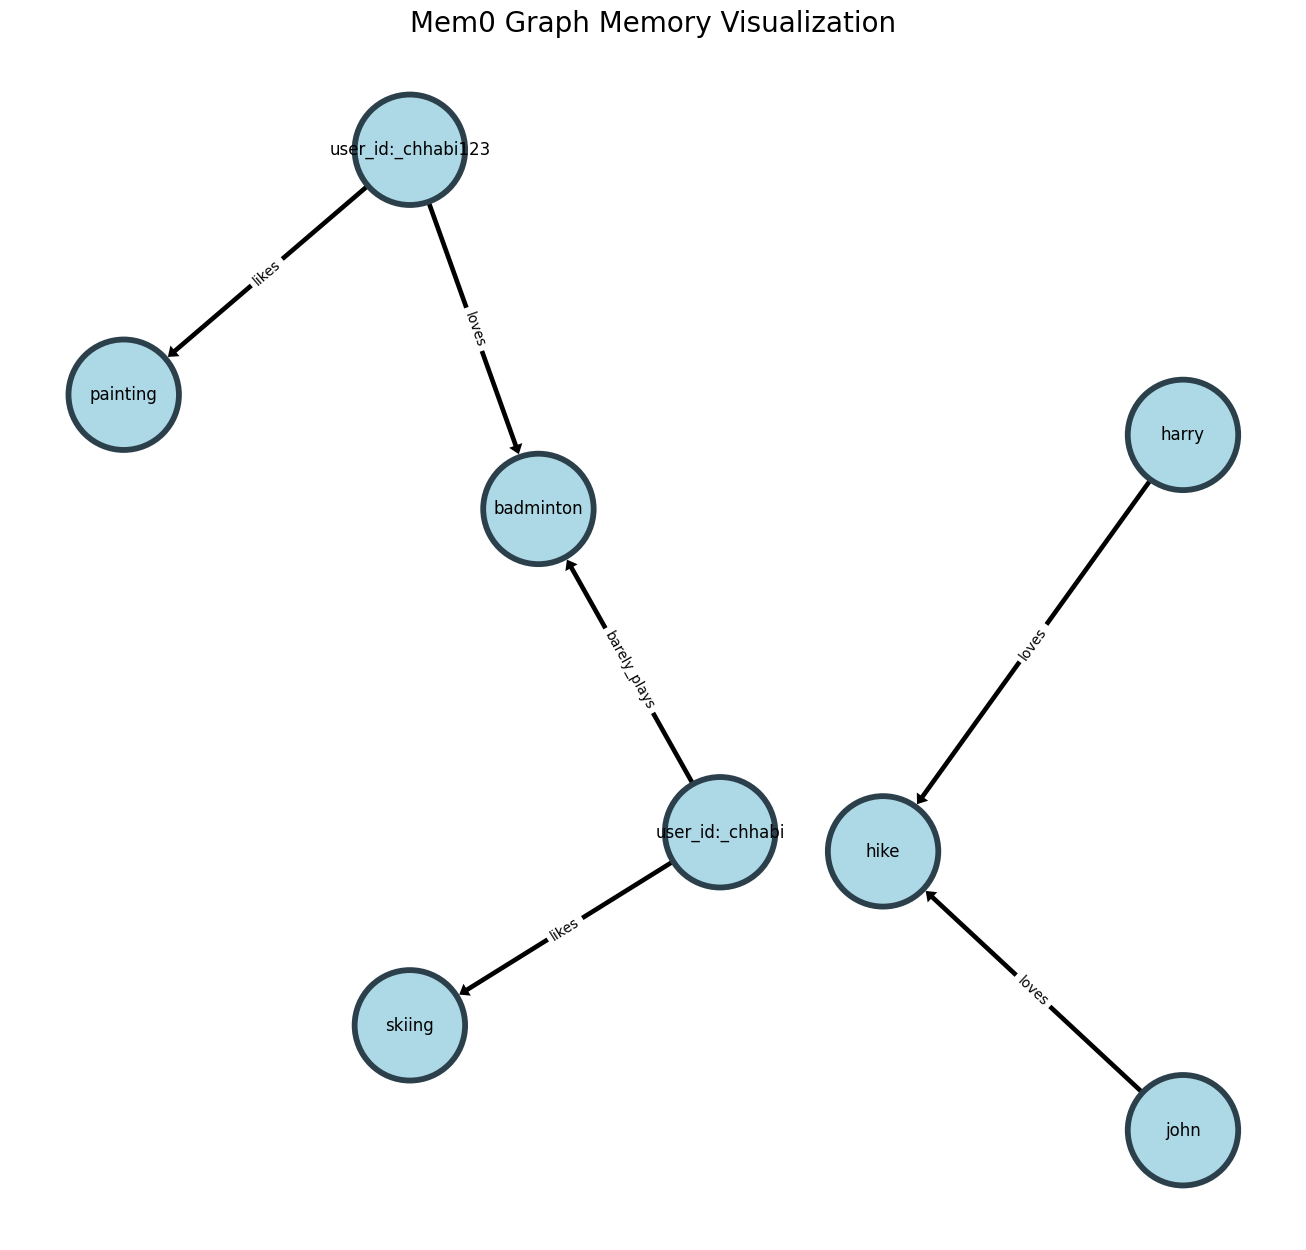

In [38]:
m_neo.add("John loves to hike and Harry loves to hike as well", user_id=user_id), display_graph()
display_graph()

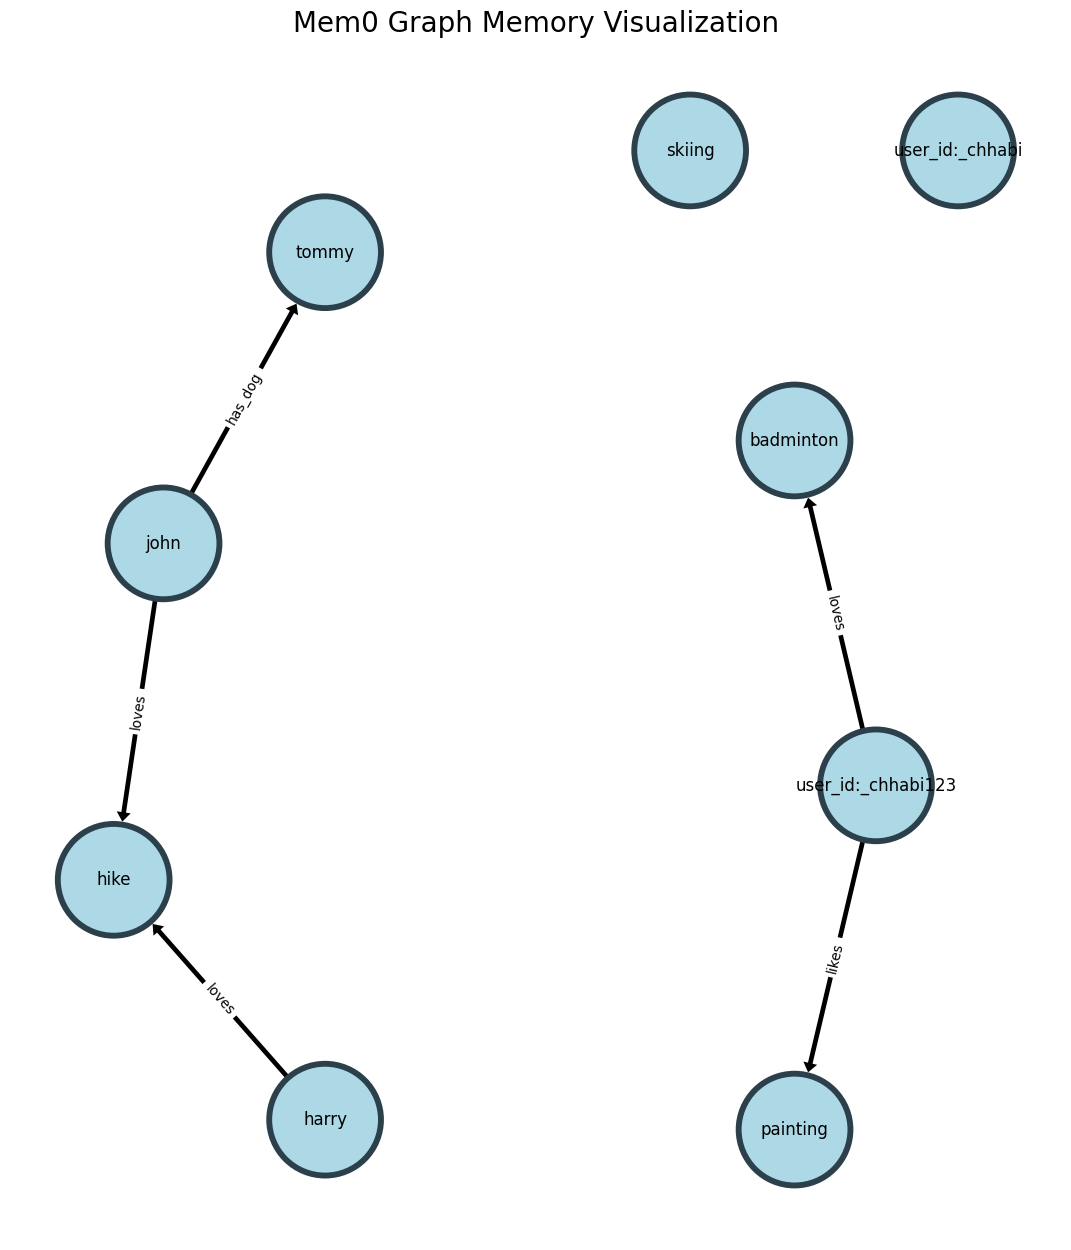

({'results': [{'id': '2eda2609-b7c4-44b2-bde1-89be910f3c80',
    'memory': "Friend's name is John",
    'event': 'ADD'},
   {'id': '1352f99c-b739-4108-84d0-7eb2ee46057c',
    'memory': 'John has a dog named Tommy',
    'event': 'ADD'}],
  'relations': {'deleted_entities': [[{'source': 'user_id:_chhabi',
      'target': 'badminton',
      'relationship': 'barely_plays'}],
    [{'source': 'user_id:_chhabi',
      'target': 'skiing',
      'relationship': 'likes'}]],
   'added_entities': [[{'source': 'john',
      'relationship': 'has_dog',
      'target': 'tommy'}]]}},
 None)

In [39]:
m_neo.add("My friend name is john and john has a dog named tommy", user_id=user_id), display_graph()

In [41]:
m_neo.get_all(user_id=user_id)

{'results': [{'id': '1352f99c-b739-4108-84d0-7eb2ee46057c',
   'memory': 'John has a dog named Tommy',
   'hash': '0416b49b6d2af65ac00fa69f03385684',
   'metadata': None,
   'created_at': '2025-08-09T06:34:10.345294-07:00',
   'updated_at': None,
   'user_id': 'chhabi'},
  {'id': '17b717ff-a4a3-4b04-bbf3-81517bf4a8b8',
   'memory': 'John loves to hike',
   'hash': 'e6282e7e388eae963f214f45c386ef4a',
   'metadata': None,
   'created_at': '2025-08-09T06:33:18.874651-07:00',
   'updated_at': None,
   'user_id': 'chhabi'},
  {'id': '2eda2609-b7c4-44b2-bde1-89be910f3c80',
   'memory': "Friend's name is John",
   'hash': '26787975c6a8668ff45d0d9ebd482b39',
   'metadata': None,
   'created_at': '2025-08-09T06:34:10.330883-07:00',
   'updated_at': None,
   'user_id': 'chhabi'},
  {'id': '490336b1-d6fd-4393-b806-80dbc2c3012c',
   'memory': 'Barely plays badminton',
   'hash': 'eabb6d59d542a37fc67bb6d0f26a7670',
   'metadata': None,
   'created_at': '2025-08-09T06:30:16.963512-07:00',
   'update

In [44]:
m_neo.search("what is the pet name of john?", user_id=user_id, limit=3)

{'results': [{'id': '1352f99c-b739-4108-84d0-7eb2ee46057c',
   'memory': 'John has a dog named Tommy',
   'hash': '0416b49b6d2af65ac00fa69f03385684',
   'metadata': None,
   'score': 0.5845703277225813,
   'created_at': '2025-08-09T06:34:10.345294-07:00',
   'updated_at': None,
   'user_id': 'chhabi'},
  {'id': '2eda2609-b7c4-44b2-bde1-89be910f3c80',
   'memory': "Friend's name is John",
   'hash': '26787975c6a8668ff45d0d9ebd482b39',
   'metadata': None,
   'score': 0.5840313776041308,
   'created_at': '2025-08-09T06:34:10.330883-07:00',
   'updated_at': None,
   'user_id': 'chhabi'},
  {'id': '17b717ff-a4a3-4b04-bbf3-81517bf4a8b8',
   'memory': 'John loves to hike',
   'hash': 'e6282e7e388eae963f214f45c386ef4a',
   'metadata': None,
   'score': 0.47927278298511505,
   'created_at': '2025-08-09T06:33:18.874651-07:00',
   'updated_at': None,
   'user_id': 'chhabi'}],
 'relations': [{'source': 'harry',
   'relationship': 'loves',
   'destination': 'hike'},
  {'source': 'john', 'relations

## REDIS

In [6]:
config = {
    "vector_store":{
        "provider": "redis",
        "config": {
            "collection_name": "mem0",
            "embedding_model_dims": 1536,
            "redis_url": "redis://:redis_mem0@localhost:6379"
        }
    }
}


In [ ]:
try:
    m_redis_2 = Memory.from_config(config)
    messages = [
        {"role": "user", "content": "I'm planning to watch a movie tonight. Any recommendations?"},
        {"role": "assistant", "content": "How about a thriller movies? They can be quite engaging."},
        {"role": "user", "content": "I’m not a big fan of thriller movies but I love sci-fi movies."},
        {"role": "assistant", "content": "Got it! I'll avoid thriller recommendations and suggest sci-fi movies in the future."}
    ]
    m_redis_2.add(messages, user_id="maya", metadata={"category": "movies"})

    print(m_redis_2.search("movies i like", user_id="maya"))

except Exception as e:
    print(f"Error: {e}")

01:02:40 redisvl.index.index INFO   Index already exists, overwriting.
01:02:40 redisvl.index.index INFO   Index already exists, overwriting.


/home/chhabi/Desktop/engineering/mem0/.venv/lib/python3.13/site-packages/mem0/utils/factory.py:101: DeprecationWarning: Function set_client is deprecated and will be removed in the next major release. Pass connection parameters in __init__.
  return vector_store_instance(**config)


01:02:43 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
01:02:44 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
01:02:45 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
01:02:46 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
01:02:46 mem0.memory.main INFO   Total existing memories: 3
01:02:51 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
01:02:51 mem0.memory.main INFO   {'id': '0', 'text': 'Planning to watch a movie tonight', 'event': 'NONE'}
01:02:51 mem0.memory.main INFO   NOOP for Memory.
01:02:51 mem0.memory.main INFO   {'id': '1', 'text': 'Loves sci-fi movies', 'event': 'NONE'}
01:02:51 mem0.memory.main INFO   NOOP for Memory.
01:02:51 mem0.memory.main INFO   {'id': '2', 'text': 'Not a big fan of thriller movies', 'event': 'NONE'}
01:02:51 mem0.memory.main INFO   NOOP for 

In [10]:
try:
    m_redis_2 = Memory.from_config(config)
    messages = [
    {"role": "user", "content": "I want to cook something new for dinner. Any ideas?"},
    {"role": "assistant", "content": "How about trying a pasta recipe? They’re easy and delicious."},
    {"role": "user", "content": "I like pasta, but I’m avoiding gluten these days."},
    {"role": "assistant", "content": "Understood! I’ll suggest gluten-free dinner recipes from now on."}
    ]
    m_redis_2.add(messages, user_id="huehue", metadata={"category": "foods"})

    print(m_redis_2.search("movies i like", user_id="huehue"))

except Exception as e:
    print(f"Error: {e}")



01:06:52 redisvl.index.index INFO   Index already exists, overwriting.
01:06:52 redisvl.index.index INFO   Index already exists, overwriting.
01:06:53 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
01:06:53 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
01:06:55 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
01:06:55 mem0.memory.main INFO   Total existing memories: 2
01:06:57 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
01:06:57 mem0.memory.main INFO   {'id': '0', 'text': 'Likes pasta', 'event': 'NONE'}
01:06:57 mem0.memory.main INFO   NOOP for Memory.
01:06:57 mem0.memory.main INFO   {'id': '1', 'text': 'Is avoiding gluten', 'event': 'NONE'}
01:06:57 mem0.memory.main INFO   NOOP for Memory.
01:06:58 httpx INFO   HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
{'results': [{'id': 'dac04916